Yeom's request: 
1) phase map을 그리자
2) 통계 추정치를 뽑아내자.

# Load Data

In [27]:
from useful import auto199

In [28]:
import imagingPhase.load_data as ld
fn = './phaseAnalysis3/2HTaSe_cea_100K037_crop.gwy'
import gwyfile
import numpy as np
container = gwyfile.load(fn)
arr = container['/15/data']['data']
arr = arr.reshape([322,1024])
print('I can read the variables in outside')


I can read the variables in outside


# Quick preprocess

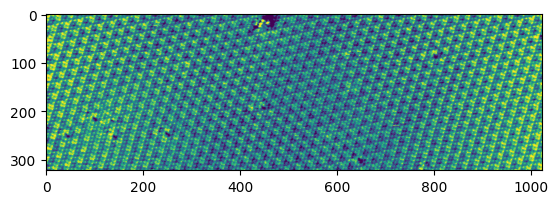

In [29]:
from matplotlib import pyplot as plt
# plt.imshow(arr[0:1000,0:1000])
plt.imshow(arr)
auto199()

In [30]:
from scipy.ndimage import gaussian_filter
def ceilcut(arr2,threshold=1*10**-10):
  arr2[arr2>threshold] = threshold
  return arr2
def highpass(arr2,sigma=5):
  
  arr2 = arr2 - gaussian_filter(arr2,sigma=sigma)
  return arr2



In [31]:
print(arr.flatten().max())
print(arr.flatten().min())

-1.452846344073277e-07
-1.4539968300437665e-07


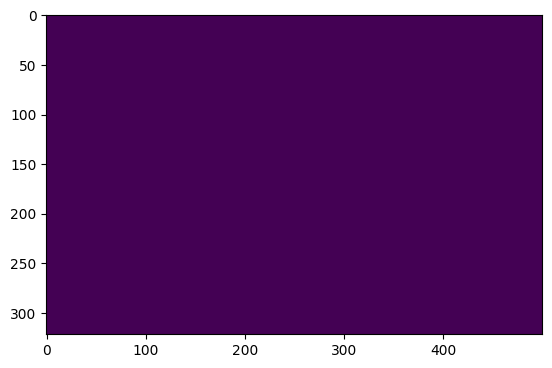

In [32]:
# plt.hist(arr.flatten().max)
plt.imshow(arr[0:500,0:500]>1*10**-10)

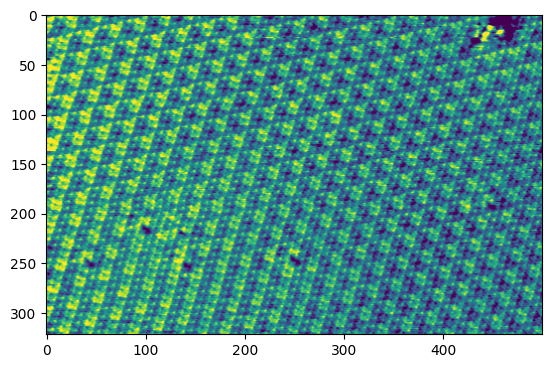

In [33]:
plt.imshow(arr[0:500,0:500])
auto199()

In [34]:
arr_after = highpass(ceilcut(arr)) 

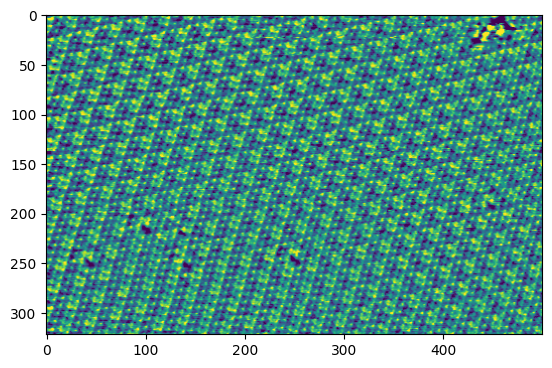

In [35]:
plt.imshow(arr_after[0:500,0:500])
auto199()

In [36]:
# from scipy.fft import fft2, fftshift
# from skimage.feature import peak_local_max
# def fft2show(arr_cln,vmin,vmax):
#   fft_result = fft2(arr_cln)
#   fft_result_shifted = fftshift(fft_result)
#   magnitude_spectrum = np.abs(fft_result_shifted)
#   plt.figure(figsize=(10, 10))
#   plt.imshow(magnitude_spectrum, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.title('Magnitude Spectrum of 2D FFT')
#   return  magnitude_spectrum
# def fft2pkfnd(fft2abs,threshold,choose):
#   coordinates = peak_local_max(fft2abs, min_distance=100, threshold_abs = threshold)
#   plt.scatter(coordinates[:, 1], coordinates[:, 0], s=50, facecolors='none', edgecolors='r')
#   for ipeak in range(coordinates.shape[0]):
#     plt.text(coordinates[ipeak,1],coordinates[ipeak,0],str(ipeak), color='g')
#   coordinates_choose = coordinates[choose,:]
#   print(coordinates_choose)
#   print(coordinates_choose.shape[0])
#   for ipeak in range(coordinates_choose.shape[0]):
#     plt.text(coordinates_choose[ipeak,1],coordinates_choose[ipeak,0],str(ipeak), color='b',size= 20)
#     pk_all = coordinates - (np.array(fft2abs.shape)/2)
#     pk_choose = pk_all[choose,:]
#   return pk_choose,pk_all
arr_cln = arr_after

In [37]:
vmin = 0 # @param
vmax = 0.0000001 # @param
threshold = 0.00000002 # @param
choose = [6,11,12] # @param

In [38]:
from imagingPhase.ffts import fft2show,fft2pkfnd

In [39]:
fft2show

<function imagingPhase.ffts.fft2show(arr_cln, vmin=None, vmax=None)>

[[148 375]
 [209 549]
 [127 612]]
3
[[ -13. -137.]
 [  48.   37.]
 [ -34.  100.]]
[[ -43.    8.]
 [  43.   -8.]
 [ -11.   33.]
 [  11.  -33.]
 [  -4.  -45.]
 [   4.   45.]
 [ -13. -137.]
 [  13.  137.]
 [ -16.  -12.]
 [  16.   12.]
 [ -48.  -37.]
 [  48.   37.]
 [ -34.  100.]
 [  34. -100.]
 [ -32.  -24.]
 [  32.   24.]
 [  -9.  -92.]
 [   9.   92.]
 [ -39.   55.]
 [  39.  -55.]
 [ -62. -174.]
 [  62.  174.]
 [ -69.  200.]
 [  69. -200.]
 [ -36.  -70.]
 [  36.   70.]
 [ -82.   63.]
 [  82.  -63.]
 [ -59.   -4.]
 [  59.    4.]
 [ -25. -104.]
 [  25.  104.]
 [ -50.   88.]
 [  50.  -88.]
 [ -28. -275.]
 [  28.  275.]
 [ -21.  238.]
 [  21. -238.]
 [ -27.   22.]
 [  27.  -22.]
 [ -80.  -60.]
 [  80.   60.]
 [ -87.   18.]
 [  87.  -18.]]


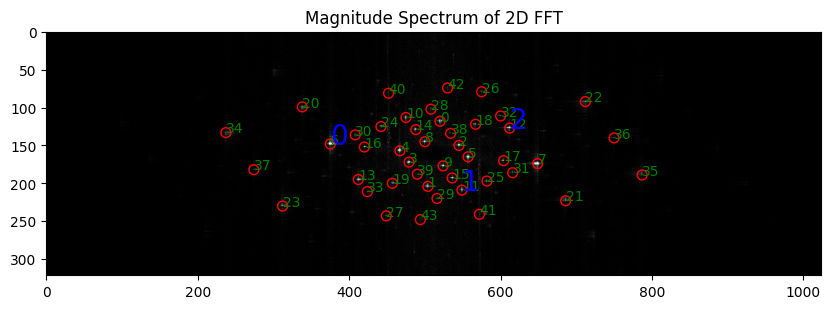

In [40]:
# from imagingPhase import fft2show
fft2abs = fft2show(arr_cln,vmin,vmax)
pk_choose,pk_all = fft2pkfnd(fft2abs,threshold,choose,min_distance=10)
print(pk_choose)
print(pk_all)

Text(0.5, 0.98, 'k0')

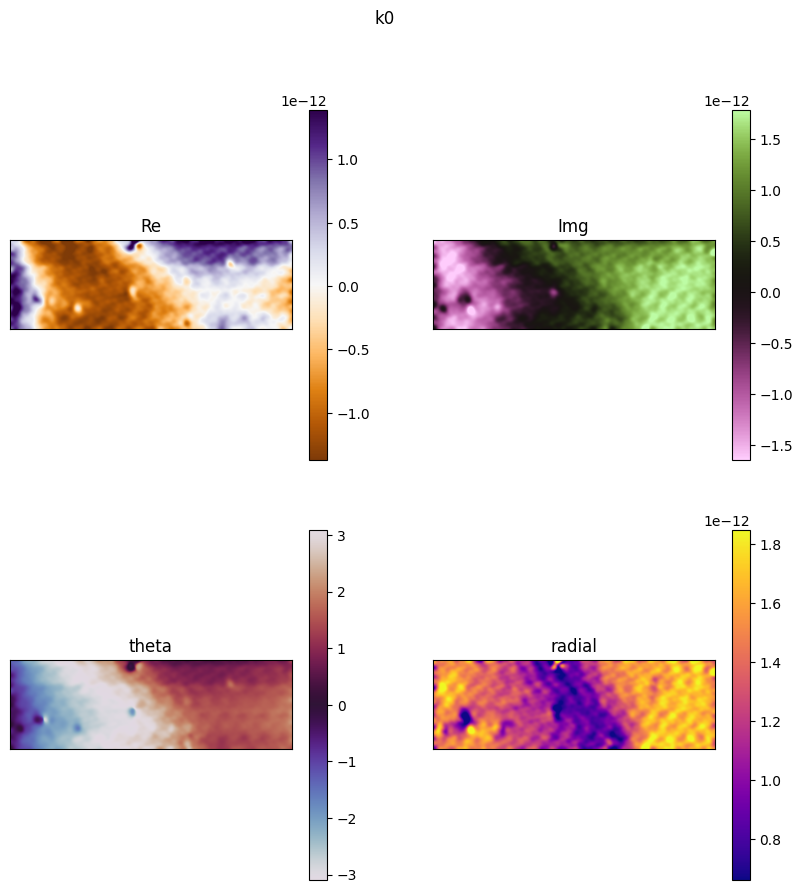

In [41]:
from imagingPhase.get_phimap import kdisplacementmap, visxprod

ik = 0 # @param
k = pk_choose[ik]/3
sig = 10 # @para
xprod = kdisplacementmap(arr_cln,k,sig)
visxprod(xprod)
plt.suptitle("k"+str(ik))


In [42]:
ks_Latt = pk_choose
ks_CDW = pk_choose/3

In [43]:
def wrap_phase(unwrapped_phase):
  """
  Wraps unwrapped phase data into the range of (-pi, pi].

  Args:
    unwrapped_phase: A numpy array containing the unwrapped phase data.

  Returns:
    A numpy array containing the wrapped phase data.
  """
  wrapped_phase = np.mod(unwrapped_phase + np.pi, 2 * np.pi) - np.pi
  return wrapped_phase
from skimage.restoration import unwrap_phase

In [ ]:

sig = 20 # @param
angle_restores = []
amps = []
complexs = []
for ik in range(3):
  k_Latt = ks_Latt[ik]
  k_CDW = ks_CDW[ik]
  complex = kdisplacementmap(arr_cln,k_CDW,sig)
  angle_restore = (unwrap_phase(np.angle(complex))- unwrap_phase(np.angle(kdisplacementmap(arr_cln,k_Latt,sig)))/3)
  angle_restores.append(angle_restore)
  complexs.append(complex)




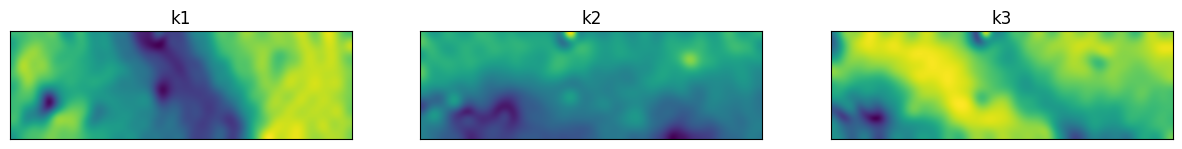

In [45]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
for ik,tn in zip(range(3),tns):
    # reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    reimg = np.abs(complexs[ik])
    axs[ik].imshow(reimg)
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

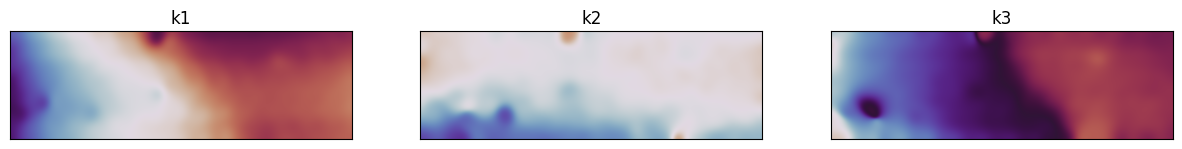

In [46]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
for ik,tn in zip(range(3),tns):
    # reimg = angle_restores[ik]
    # reimg = wrap_phase(reimg)
    reimg = np.angle(complexs[ik])
    axs[ik].imshow(reimg,cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

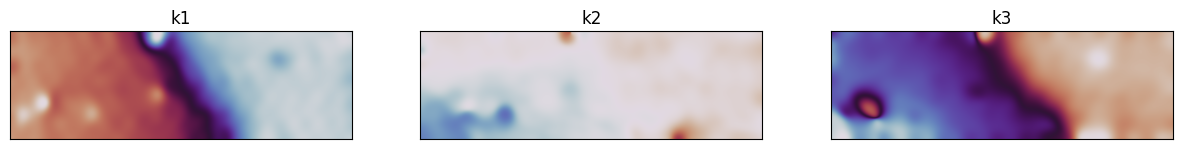

In [47]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
phis = np.array([-1,0,0])*np.pi*(2/3)
for ik,tn,phi in zip(range(3),tns,phis):
    reimg = angle_restores[ik] +phi
    reimg = wrap_phase(reimg) 
    axs[ik].imshow(reimg, cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])

In [48]:
pk_choose

array([[ -13., -137.],
       [  48.,   37.],
       [ -34.,  100.]])

In [ ]:
complexs

NameError: name 'complexes' is not defined

In [ ]:
len(complexs)
foo = 

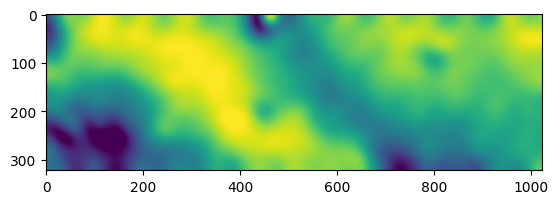

In [60]:

plt.imshow(foo[2])
auto199()

In [63]:
new_dt = {'fns':'100K',
    'arr_clns':arr_cln,
    'colors':'k',
    'nms':'100K',
    'Ts':100,
    'nano':40,
    'sz':1024,
    'pxl20nm':512,
    'k123':pk_choose,
    'phase':angle_restores,
    'amplitude':list(map(abs,complexs))}
import pickle
with open('dataCache/h02.pkl','wb') as f:
    pickle.dump(new_dt,f)